# 13.워드 클라우드 만들기
- 인터넷에서 좋은 글(연설문, 혹은 기사, 책 내용 등)을 찾아, txt로 저장하고 읽어와 워드 클라우드 만들어 보기

## 13.1.워드클라우드(wordcloud)란?
> 단어나 문장에서 자주 등장하는 단어들을, 글자 크기로 표현한 그림

- 단어가 많이 나올수록 크고 굵게 보임
- 단어가 적게 나올수록 작고 연하게 보임
- https://github.com/amueller/word_cloud

## 13.2.현실 예시
- 뉴스 기사 분석: 자주 나오는 단어를 시각화해서 핵심 키워드 파악
- 인터뷰나 리뷰 분석: 사람들이 어떤 단어를 많이 썼는지 쉽게 확인
- 설문조사 의견 분석: 자유답변을 시각화하여 트렌드 보기
- SNS 분석: 트위터, 블로그 글에서 자주 나오는 단어 파악

## 13.3.워드 클라우드 만드는 순서

1) 텍스트파일로 저장하기

    - 읽을 파일을 만듭니다.
    - 여기서는 수동으로 어디선가 가져오겠지만,
    - 나중에는 크롤링을 통해서 웹에서 가져올 수도 있습니다.
    
    
2) 텍스트 전처리

    - 파일을 읽어서 split() 메소드를 사용해 단어 단위로 쪼갭니다.
    - 단어별 빈도수를 계산하여 딕셔너리 형태로 저장합니다.
    - 분석에 의미가 없는 조사들은 제거합니다.
    
3) 워드 클라우드 그리기

    -  wordcloud 라이브러리를 설치한 후 불러옵니다.
    - 워드 클라우드를 그립니다.

**1) 텍스트 파일로 저장하기**

**2) 텍스트 전처리**
- 우선 파일을 읽어와 내용을 확인한다.
- 한글 파일을 읽어올 때 인코딩 오류가 발생하면 encoding='CP949'로 지정한다. 또는, encoding='UTF-8'로 지정한다.

In [ ]:
f = open('./assets/인연.txt', 'r',encoding='UTF-8')

text = f.read()
f.close()

f.close()

text[:100]

'지난 사월 춘천에 가려고 하다가 못 가고 말았다. 나는 성심여자대학에 가보고\n싶었다. 그 학교에 어느 가을 학기, 매주 한 번씩 출강한 일이 있다. 힘드는 출강을 한\n학기 하게 된'

- split() 메소드를 사용해 단어 단위로 잘라 리스트 형태로 만든다.

In [4]:
print(text)

지난 사월 춘천에 가려고 하다가 못 가고 말았다. 나는 성심여자대학에 가보고
싶었다. 그 학교에 어느 가을 학기, 매주 한 번씩 출강한 일이 있다. 힘드는 출강을 한
학기 하게 된 것은, 주 수녀님과 김 수녀님이 내 집에 오신 것에 대한 예의도
있었지만 나에게는 사연이 있었다.
  수십 년 전 내가 열일곱 되던 봄, 나는 처음 동경에 간 일이 있다. 어떤 분의 소개로
사회 교육가 미우라 선생 댁에 유숙을 하게 되었다. 시바꾸 시로가네에 있는 그
집에는 주인 내외와 어린 딸 세 식구가 살고 있었다. 하녀도 서생도 없었다. 눈이
예쁘고 웃는 얼굴을 하는 아사꼬는 처음부터 나를 오빠같이 따랐다. 아침에 낳았다고
아사꼬라는 이름을 지어주었다고 하였다. 그 집 뜰에는 큰 나무들이 있었고 일년초
꽃도 많았다. 내가 간 이튿날 아침, 아사꼬는 '스위트피'를 따다가 꽃병에 담아 내가
쓰게 된 책상 위에 놓아주었다. '스위트피'는 아사꼬같이 어리고 귀여운 꽃이라고
생각하였다.
  성심 여학원 소학교 일 학년인 아사꼬는 어느 토요일 오후 나와 같이 저희 학교까지
산보를 갔었다. 유치원부터 학부까지 있는 가톨릭 교육 기관으로 유명한 이 여학원은
시내에 있으면서 큰 목장까지 가지고 있었다. 아사꼬는 자기 신발장을 열고 교실에서
신는 하얀 운동화를 보여주었다.
  내가 동경을 떠나던 날 아침, 아사꼬는 내 목을 안고 내 뺨에 입을 맞추고, 제가
쓰던 작은 손수건과 제가 끼던 작은 반지를 이별의 선물로 주었다. 옆에서 보고 있던
선생 부인은 웃으면서 "한 십년 지나면 좋은 상대가 될 거^36^예요" 하였다. 나는
얼굴이 더워지는 것을 느꼈다. 나는 아사꼬에게 안델센의 동화책을 주었다.
  그후 십 년이 지나고 삼사 년이 더 지났다. 그동안 나는 국민학교 일 학년 같은
예쁜 여자 아이를 보면 아사꼬 생각을 하였다. 내가 두번째 동경에 갔던 것도
사월이었다. 동경역 가까운 데 여관을 정하고 즉시 미우라 댁을 찾아갔다. 아사꼬는
어느덧 청순하고 세련되어 보이는 영양이 되어 있었다. 그 집 

In [5]:
wordlist = []

print(text.split())

['지난', '사월', '춘천에', '가려고', '하다가', '못', '가고', '말았다.', '나는', '성심여자대학에', '가보고', '싶었다.', '그', '학교에', '어느', '가을', '학기,', '매주', '한', '번씩', '출강한', '일이', '있다.', '힘드는', '출강을', '한', '학기', '하게', '된', '것은,', '주', '수녀님과', '김', '수녀님이', '내', '집에', '오신', '것에', '대한', '예의도', '있었지만', '나에게는', '사연이', '있었다.', '수십', '년', '전', '내가', '열일곱', '되던', '봄,', '나는', '처음', '동경에', '간', '일이', '있다.', '어떤', '분의', '소개로', '사회', '교육가', '미우라', '선생', '댁에', '유숙을', '하게', '되었다.', '시바꾸', '시로가네에', '있는', '그', '집에는', '주인', '내외와', '어린', '딸', '세', '식구가', '살고', '있었다.', '하녀도', '서생도', '없었다.', '눈이', '예쁘고', '웃는', '얼굴을', '하는', '아사꼬는', '처음부터', '나를', '오빠같이', '따랐다.', '아침에', '낳았다고', '아사꼬라는', '이름을', '지어주었다고', '하였다.', '그', '집', '뜰에는', '큰', '나무들이', '있었고', '일년초', '꽃도', '많았다.', '내가', '간', '이튿날', '아침,', '아사꼬는', "'스위트피'를", '따다가', '꽃병에', '담아', '내가', '쓰게', '된', '책상', '위에', '놓아주었다.', "'스위트피'는", '아사꼬같이', '어리고', '귀여운', '꽃이라고', '생각하였다.', '성심', '여학원', '소학교', '일', '학년인', '아사꼬는', '어느', '토요일', '오후', '나와', '같이', '저희', '학교까지', '산보를', '갔었다.', '유치원부터', '학부까지', '있는', 

In [6]:

wordlist = []

# 한글자, 마침표가 있는 단어 제거

for x in text.split():
    if '.' in x:
        pass
    elif len(x) == 1:
        pass
    else:
        wordlist.append(x)

# print(wordlist[:10])
print(wordlist)

['지난', '사월', '춘천에', '가려고', '하다가', '가고', '나는', '성심여자대학에', '가보고', '학교에', '어느', '가을', '학기,', '매주', '번씩', '출강한', '일이', '힘드는', '출강을', '학기', '하게', '것은,', '수녀님과', '수녀님이', '집에', '오신', '것에', '대한', '예의도', '있었지만', '나에게는', '사연이', '수십', '내가', '열일곱', '되던', '봄,', '나는', '처음', '동경에', '일이', '어떤', '분의', '소개로', '사회', '교육가', '미우라', '선생', '댁에', '유숙을', '하게', '시바꾸', '시로가네에', '있는', '집에는', '주인', '내외와', '어린', '식구가', '살고', '하녀도', '서생도', '눈이', '예쁘고', '웃는', '얼굴을', '하는', '아사꼬는', '처음부터', '나를', '오빠같이', '아침에', '낳았다고', '아사꼬라는', '이름을', '지어주었다고', '뜰에는', '나무들이', '있었고', '일년초', '꽃도', '내가', '이튿날', '아침,', '아사꼬는', "'스위트피'를", '따다가', '꽃병에', '담아', '내가', '쓰게', '책상', '위에', "'스위트피'는", '아사꼬같이', '어리고', '귀여운', '꽃이라고', '성심', '여학원', '소학교', '학년인', '아사꼬는', '어느', '토요일', '오후', '나와', '같이', '저희', '학교까지', '산보를', '유치원부터', '학부까지', '있는', '가톨릭', '교육', '기관으로', '유명한', '여학원은', '시내에', '있으면서', '목장까지', '가지고', '아사꼬는', '자기', '신발장을', '열고', '교실에서', '신는', '하얀', '운동화를', '내가', '동경을', '떠나던', '아침,', '아사꼬는', '목을', '안고', '뺨에', '입을', '맞추고,', '제가', '쓰던', '작은', '손수건과',

- 단어별 빈도수를 계산하여 딕셔너리로 저장한다.

In [7]:
# 중복단어 제거
print(wordlist)
word_clean = set(wordlist)
wordCount = {}

for w in word_clean:
    wordCount[w] = wordlist.count(w)

print(wordCount)

['지난', '사월', '춘천에', '가려고', '하다가', '가고', '나는', '성심여자대학에', '가보고', '학교에', '어느', '가을', '학기,', '매주', '번씩', '출강한', '일이', '힘드는', '출강을', '학기', '하게', '것은,', '수녀님과', '수녀님이', '집에', '오신', '것에', '대한', '예의도', '있었지만', '나에게는', '사연이', '수십', '내가', '열일곱', '되던', '봄,', '나는', '처음', '동경에', '일이', '어떤', '분의', '소개로', '사회', '교육가', '미우라', '선생', '댁에', '유숙을', '하게', '시바꾸', '시로가네에', '있는', '집에는', '주인', '내외와', '어린', '식구가', '살고', '하녀도', '서생도', '눈이', '예쁘고', '웃는', '얼굴을', '하는', '아사꼬는', '처음부터', '나를', '오빠같이', '아침에', '낳았다고', '아사꼬라는', '이름을', '지어주었다고', '뜰에는', '나무들이', '있었고', '일년초', '꽃도', '내가', '이튿날', '아침,', '아사꼬는', "'스위트피'를", '따다가', '꽃병에', '담아', '내가', '쓰게', '책상', '위에', "'스위트피'는", '아사꼬같이', '어리고', '귀여운', '꽃이라고', '성심', '여학원', '소학교', '학년인', '아사꼬는', '어느', '토요일', '오후', '나와', '같이', '저희', '학교까지', '산보를', '유치원부터', '학부까지', '있는', '가톨릭', '교육', '기관으로', '유명한', '여학원은', '시내에', '있으면서', '목장까지', '가지고', '아사꼬는', '자기', '신발장을', '열고', '교실에서', '신는', '하얀', '운동화를', '내가', '동경을', '떠나던', '아침,', '아사꼬는', '목을', '안고', '뺨에', '입을', '맞추고,', '제가', '쓰던', '작은', '손수건과',

In [8]:
# 불용어 제거 (조사 제거)
stop_words = ['그리고', '있는', '이런', '그는', '아니', '같은', '내가', '나는']

# 제외하기
for w in stop_words:
    if w in wordCount:
        del wordCount[w]

print(wordCount)


{'되어': 1, '나와': 1, '소양강': 1, '싶다고': 1, '아사꼬에게': 2, '이청산': 1, '만나게': 1, '무렵,': 1, '학부까지': 1, '번씩': 1, '얼굴로': 1, '되지는': 1, '집도': 1, '교실에는': 1, '스치고': 1, '만났어야': 1, '아직도': 1, '악수를': 1, '쓰게': 1, '고왔던': 1, '있었나': 1, '전문|작성자': 1, '예쁜': 1, '결혼하였다는': 1, '위에': 1, '백합같이': 1, '전쟁': 2, '고스란히': 1, '소설': 2, '남편이': 1, '산다는': 1, '않았나': 1, '아버지': 1, '꽃이라고': 1, '나고': 1, '먹기': 1, '학교까지': 1, '가고': 1, '하곤': 1, '재회를': 1, '이십여': 1, '집에': 2, '생각이': 1, '영문과': 1, '어디': 1, '하였을': 1, '십여': 1, '아름다울': 1, '쓰던': 1, '좋은': 1, '"한': 1, '눈이': 1, '상대가': 1, '지난': 1, '돼서': 1, '그때': 1, '나의': 1, '가던': 1, '그만큼': 1, '안내해': 1, '자기': 1, '주말에는': 1, '좋아한': 1, '1954': 1, "'인연'": 1, '가까운': 1, '하는': 1, '피어': 1, '문학': 1, '이야기한': 1, '미우라': 4, '쳐다보다가,': 1, '사회': 1, '낳았다고': 1, '지나면': 1, '있었고': 2, '구두를': 1, '우산"이라는': 1, '영양이': 1, '동화책을': 1, '뜻밖에': 1, '것과': 1, '교실에서': 1, '운동화를': 1, '담아': 1, '"쉘부르의': 1, '악수도': 1, '말을': 1, '되던': 1, '살고': 2, '때면': 1, '아닌,': 1, '마주친': 1, '사람도': 2, '미국': 2, '잊어버리고': 1, '무슨': 1, '"세월"이란': 1, '유명한': 1, '피천득': 1, 

**3) 워드 클라우드 그리기**
- wordcloud 패키지를 설치하고, 워드 클라우드를 그린다.

In [9]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
# 해상도를 높이는 코드
%config InlineBackend.figure_format='retina'

In [ ]:
# 라이브러리 불러오기
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 워드 클라우드 만들기

wordcloud = WordCloud(
    font_path='./assets/NanumBarunGothic.ttf',
    width=2000,
    height=1000,
    max_font_size=100,
    background_color='white'
).generate_from_frequencies(wordCount)

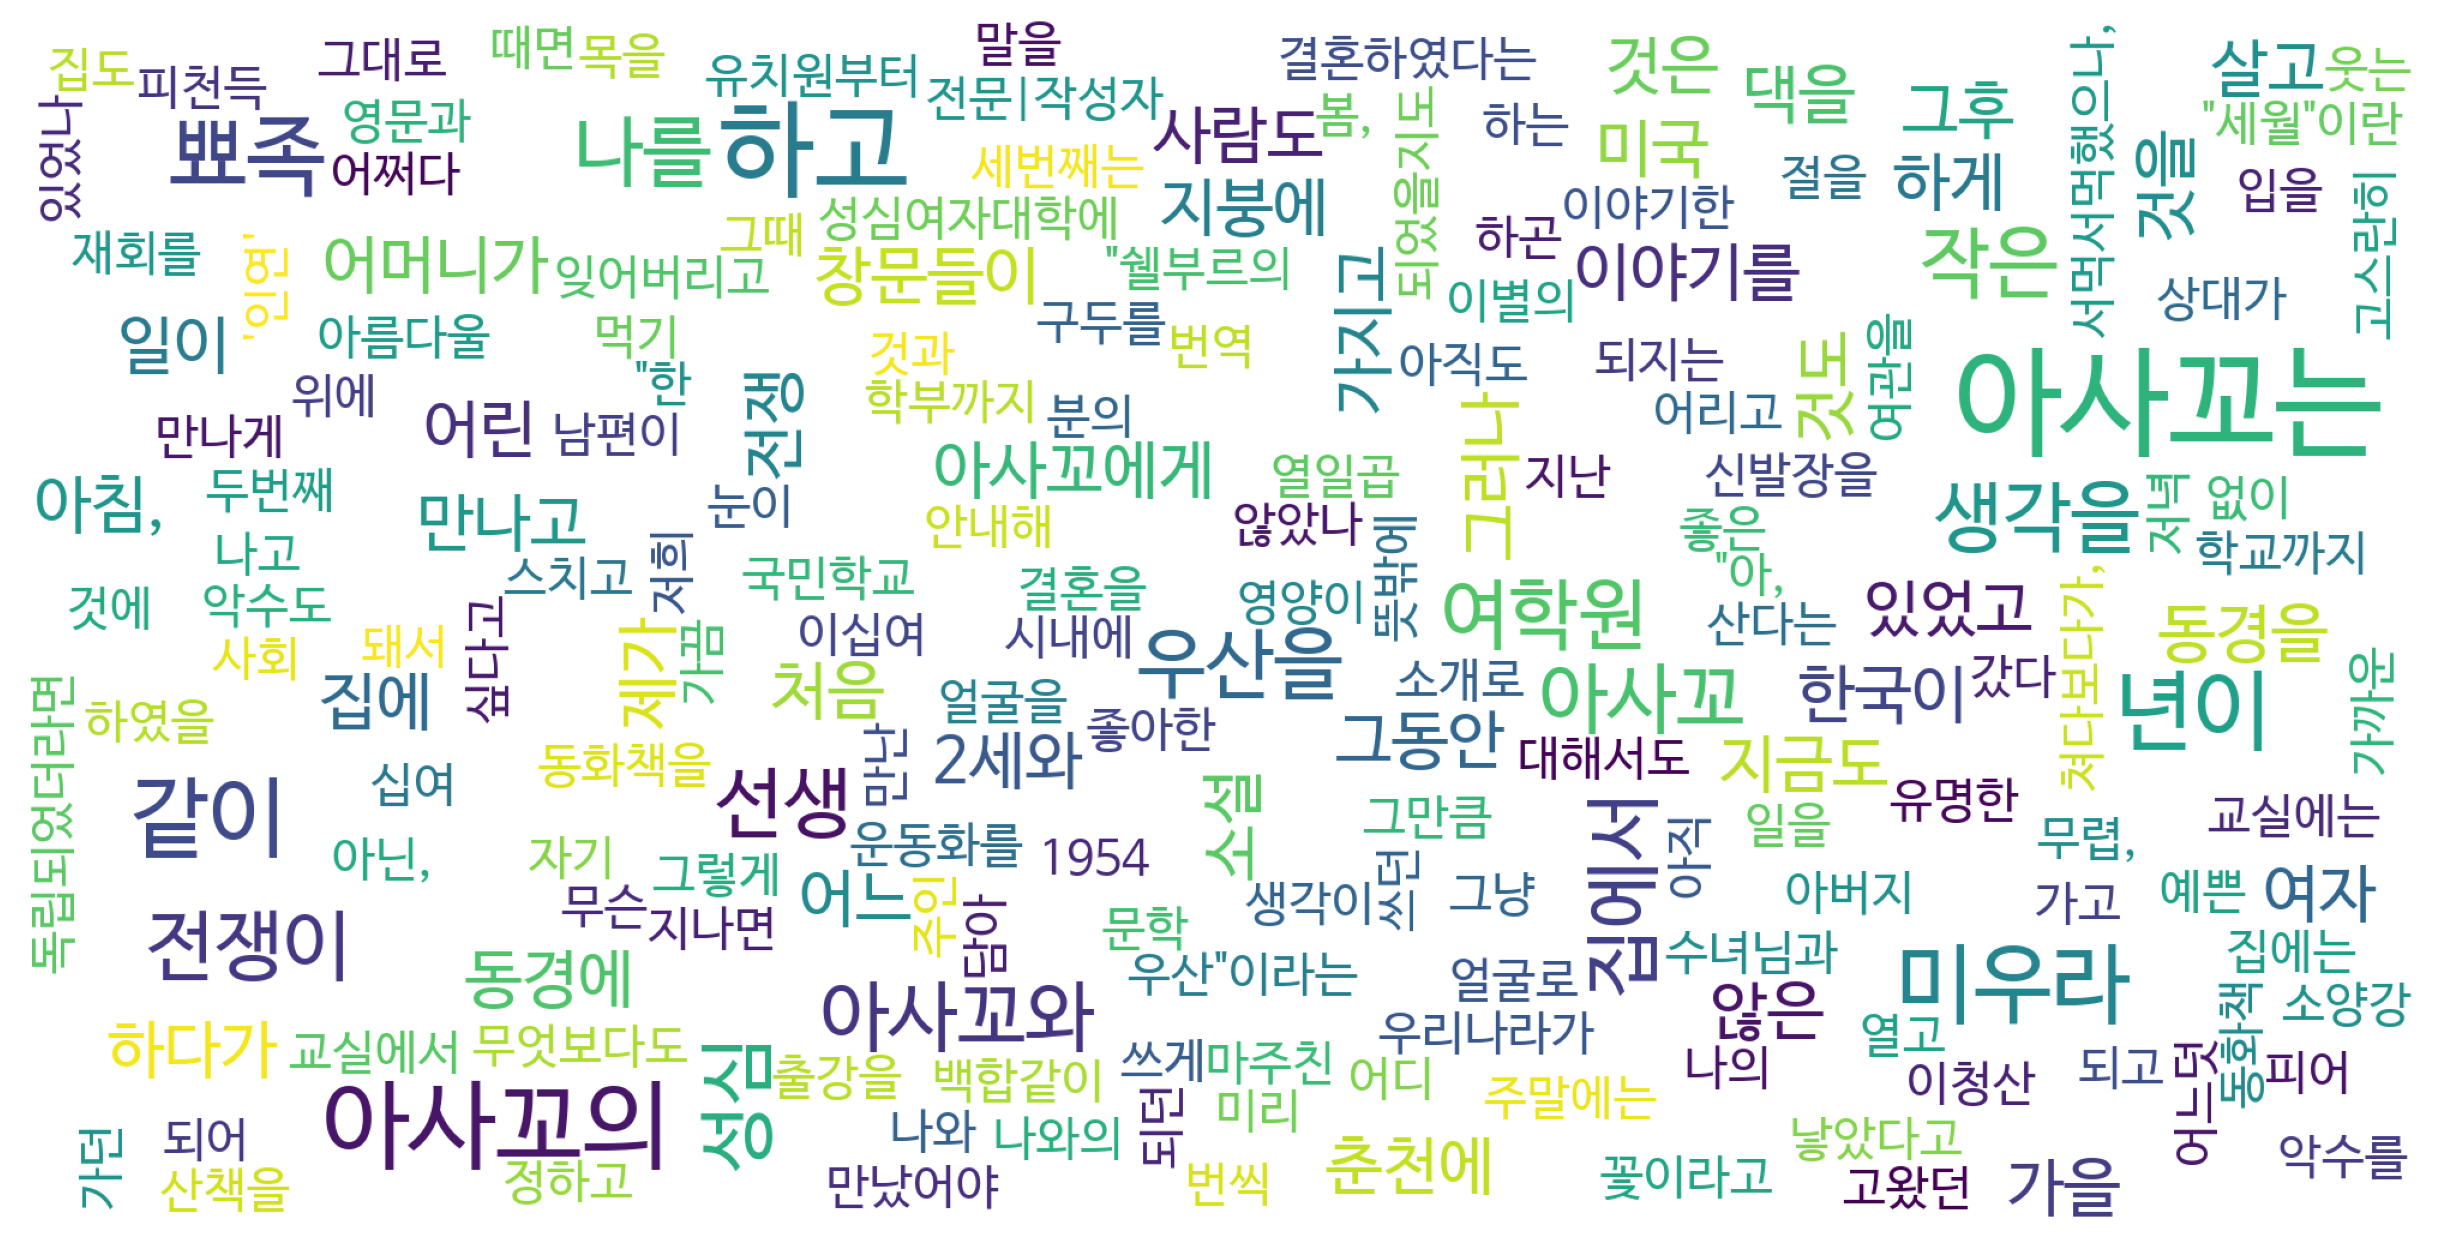

In [12]:
#표시하기
plt.figure(figsize=(12,6)) # 그래프(figure) 크기 설정 (가로 12, 세로 6 인치)
plt.imshow(wordcloud) # 워드클라우드 이미지를 화면에 표시
plt.axis('off') # x축, y축 눈금 제거 -> 깔끔하게 보이게 함
plt.tight_layout(pad=0) # 그래프 여백 최소화 (이미지가 꽉 차게)
plt.show() # 최종적으로 화면에 출력

- 이미지나 글씨 위에 워드클라우드 만들기

In [ ]:
# 라이브러리 불러오기
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 라이브러리 불러오기
import numpy as np
from PIL import Image

# 이미지를 불러오기
masking_image = np.array(Image.open('인연.jpg'))


wordcloud = WordCloud(
    font_path='./assets/NanumBarunGothic.ttf',
    width=2000,
    height=1000,
    mask = masking_image,
    max_font_size=100,
    background_color='white'
).generate_from_frequencies(wordCount)

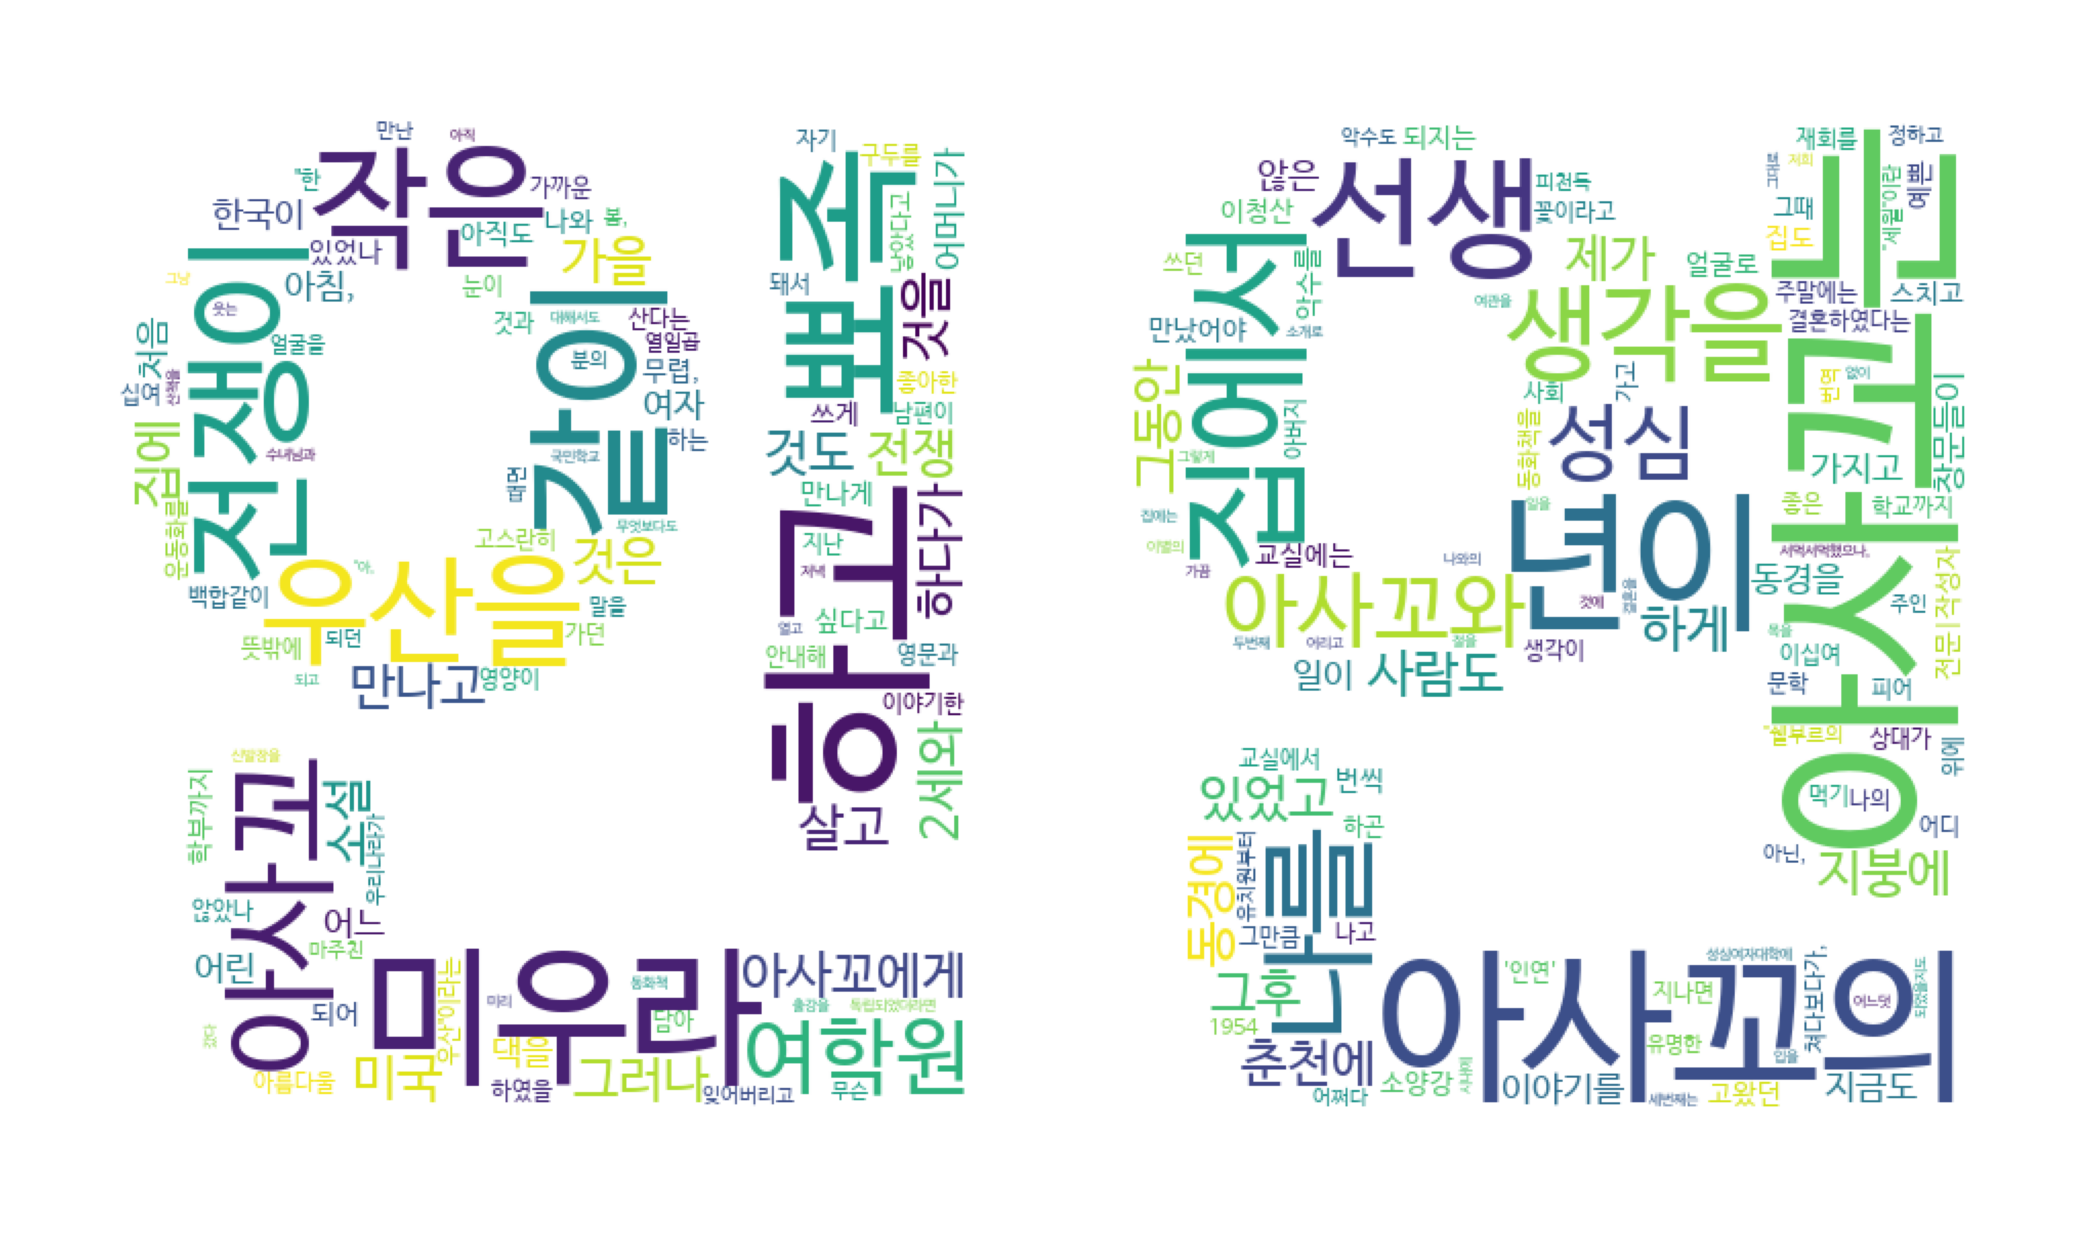

In [18]:
#표시하기
plt.figure(figsize=(12,6)) # 그래프(figure) 크기 설정 (가로 12, 세로 6 인치)
plt.imshow(wordcloud) # 워드클라우드 이미지를 화면에 표시
plt.axis('off') # x축, y축 눈금 제거 -> 깔끔하게 보이게 함
plt.tight_layout(pad=0) # 그래프 여백 최소화 (이미지가 꽉 차게)
plt.show() # 최종적으로 화면에 출력

## 실습
1. 워드 클라우드 만들기
    - a.  데이터 수집 후 txt 파일을 만들어 업로드
    - b. 데이터 전처리
        - (심화)
            - 불용어 사전
            - NLP 형태소 분석
            - 다양한 전처리
    - c. 워드 클라우드 만들기
2. 디스코드 강의 실시간 워드 클라우드 업로드

In [ ]:
f = open('./assets/time-machine.txt', 'r',encoding='UTF-8')

text = f.read()

f.close()

text[:100]

# print(text.split())
wordlist = []


# 한글자, 마침표가 있는 단어 제거

for x in text.split():
    if '.' in x:
        pass
    elif len(x) == 1:
        pass
    elif '?' in x:
        wordlist.append(x.replace('?',''))
    elif '은' in x:
        wordlist.append(x.replace('은',''))
    elif '는' in x:
        wordlist.append(x.replace('는',''))
    elif '에' in x:
        wordlist.append(x.replace('에',''))
    elif '이' in x:
        wordlist.append(x.replace('이',''))
    else:
        wordlist.append(x)

print(wordlist)



['화장하고,', '하힐', '신고', '걷', '예뻐', '보였어', '근데', '어른', '되고', '알았어', '쌩얼', '운동화가', '최고', '출근해서', '사원증', '걸고', '일하면', '멋져', '보였어', '근데', '어른', '되고', '알았어', '칼퇴', '빨간날', '최고', '다시', '어릴', '적으로', '돌아갈래', '타임머신', '올라탈래', '돌아가서', '어린', '나게', '깨라고', '말해줄래', '근데', '시동', '걸리지', '고장', '났나', '그럼', '방법', '없네', '받아들일', '수밖', 'oh-yeah', '독립하고', '돈도', '벌고', '쇼핑하', '부러웠어', '근데', '어른', '되고', '알았어', '월세와', '카드값의', '세상', '남자,', '여자', '알콩달콩', '사랑하면', '좋아', '보였어', '근데', '어른', '돼도', '모르네', '짝', '어디', '있지', '다시', '어릴', '적으로', '돌아갈래', '타임머신', '올라탈래', '돌아가서', '어린', '나게', '깨라고', '말해줄래', '근데', '시동', '걸리지', '고장', '났나', '그럼', '방법', '없네', '받아들일', '수밖', '어라,', '시동', '걸리지', '고장', '났나', '그럼', '방법', '없네', '받아들일', '수밖', '멋진', '어른', '되어', '보자', '앞만', '보고', '달려가자', '자동차', '시동을', '걸어보자', '부릉부릉,', '부르릉', 'oh-yeah']


In [62]:
# 중복단어 제거
clean_text = set(wordlist)
wordCount = {}

# print(clean_text)

for w in clean_text:
    wordCount[w] = text.count(w)

print(wordCount)

{'부릉부릉,': 1, '타임머신': 2, '되어': 1, '부러웠어': 1, '짝': 1, '시동을': 1, '그럼': 3, '좋아': 1, '보고': 1, '달려가자': 1, '말해줄래': 2, '받아들일': 3, '걸고': 1, '되고': 3, '화장하고,': 1, '어라,': 1, '돼도': 1, '신고': 1, '돌아가서': 2, '근데': 6, '돌아갈래': 2, '보였어': 3, '벌고': 1, '났나': 3, '예뻐': 1, '알콩달콩': 1, '출근해서': 1, '다시': 2, '적으로': 2, '올라탈래': 2, '시동': 4, '빨간날': 1, '어린': 2, '방법': 3, '쇼핑하': 1, '운동화가': 1, '월세와': 1, 'oh-yeah': 2, '카드값의': 1, '세상': 1, '사원증': 1, '칼퇴': 1, '수밖': 3, '걸어보자': 1, '최고': 2, '모르네': 1, '멋진': 1, '부르릉': 1, '사랑하면': 1, '하힐': 0, '어릴': 2, '없네': 3, '있지': 0, '어디': 1, '어른': 5, '독립하고': 1, '앞만': 1, '멋져': 1, '나게': 0, '돈도': 1, '남자,': 1, '여자': 1, '걷': 1, '깨라고': 2, '자동차': 1, '알았어': 3, '고장': 3, '보자': 2, '일하면': 1, '쌩얼': 1, '걸리지': 3}


In [63]:
# 불용어 제거 (조사 제거)
stop_words = ['근데', '수밖에', '그럼']

# 제외하기
for w in stop_words:
    if w in wordCount:
        del wordCount[w]

print(wordCount)


{'부릉부릉,': 1, '타임머신': 2, '되어': 1, '부러웠어': 1, '짝': 1, '시동을': 1, '좋아': 1, '보고': 1, '달려가자': 1, '말해줄래': 2, '받아들일': 3, '걸고': 1, '되고': 3, '화장하고,': 1, '어라,': 1, '돼도': 1, '신고': 1, '돌아가서': 2, '돌아갈래': 2, '보였어': 3, '벌고': 1, '났나': 3, '예뻐': 1, '알콩달콩': 1, '출근해서': 1, '다시': 2, '적으로': 2, '올라탈래': 2, '시동': 4, '빨간날': 1, '어린': 2, '방법': 3, '쇼핑하': 1, '운동화가': 1, '월세와': 1, 'oh-yeah': 2, '카드값의': 1, '세상': 1, '사원증': 1, '칼퇴': 1, '수밖': 3, '걸어보자': 1, '최고': 2, '모르네': 1, '멋진': 1, '부르릉': 1, '사랑하면': 1, '하힐': 0, '어릴': 2, '없네': 3, '있지': 0, '어디': 1, '어른': 5, '독립하고': 1, '앞만': 1, '멋져': 1, '나게': 0, '돈도': 1, '남자,': 1, '여자': 1, '걷': 1, '깨라고': 2, '자동차': 1, '알았어': 3, '고장': 3, '보자': 2, '일하면': 1, '쌩얼': 1, '걸리지': 3}


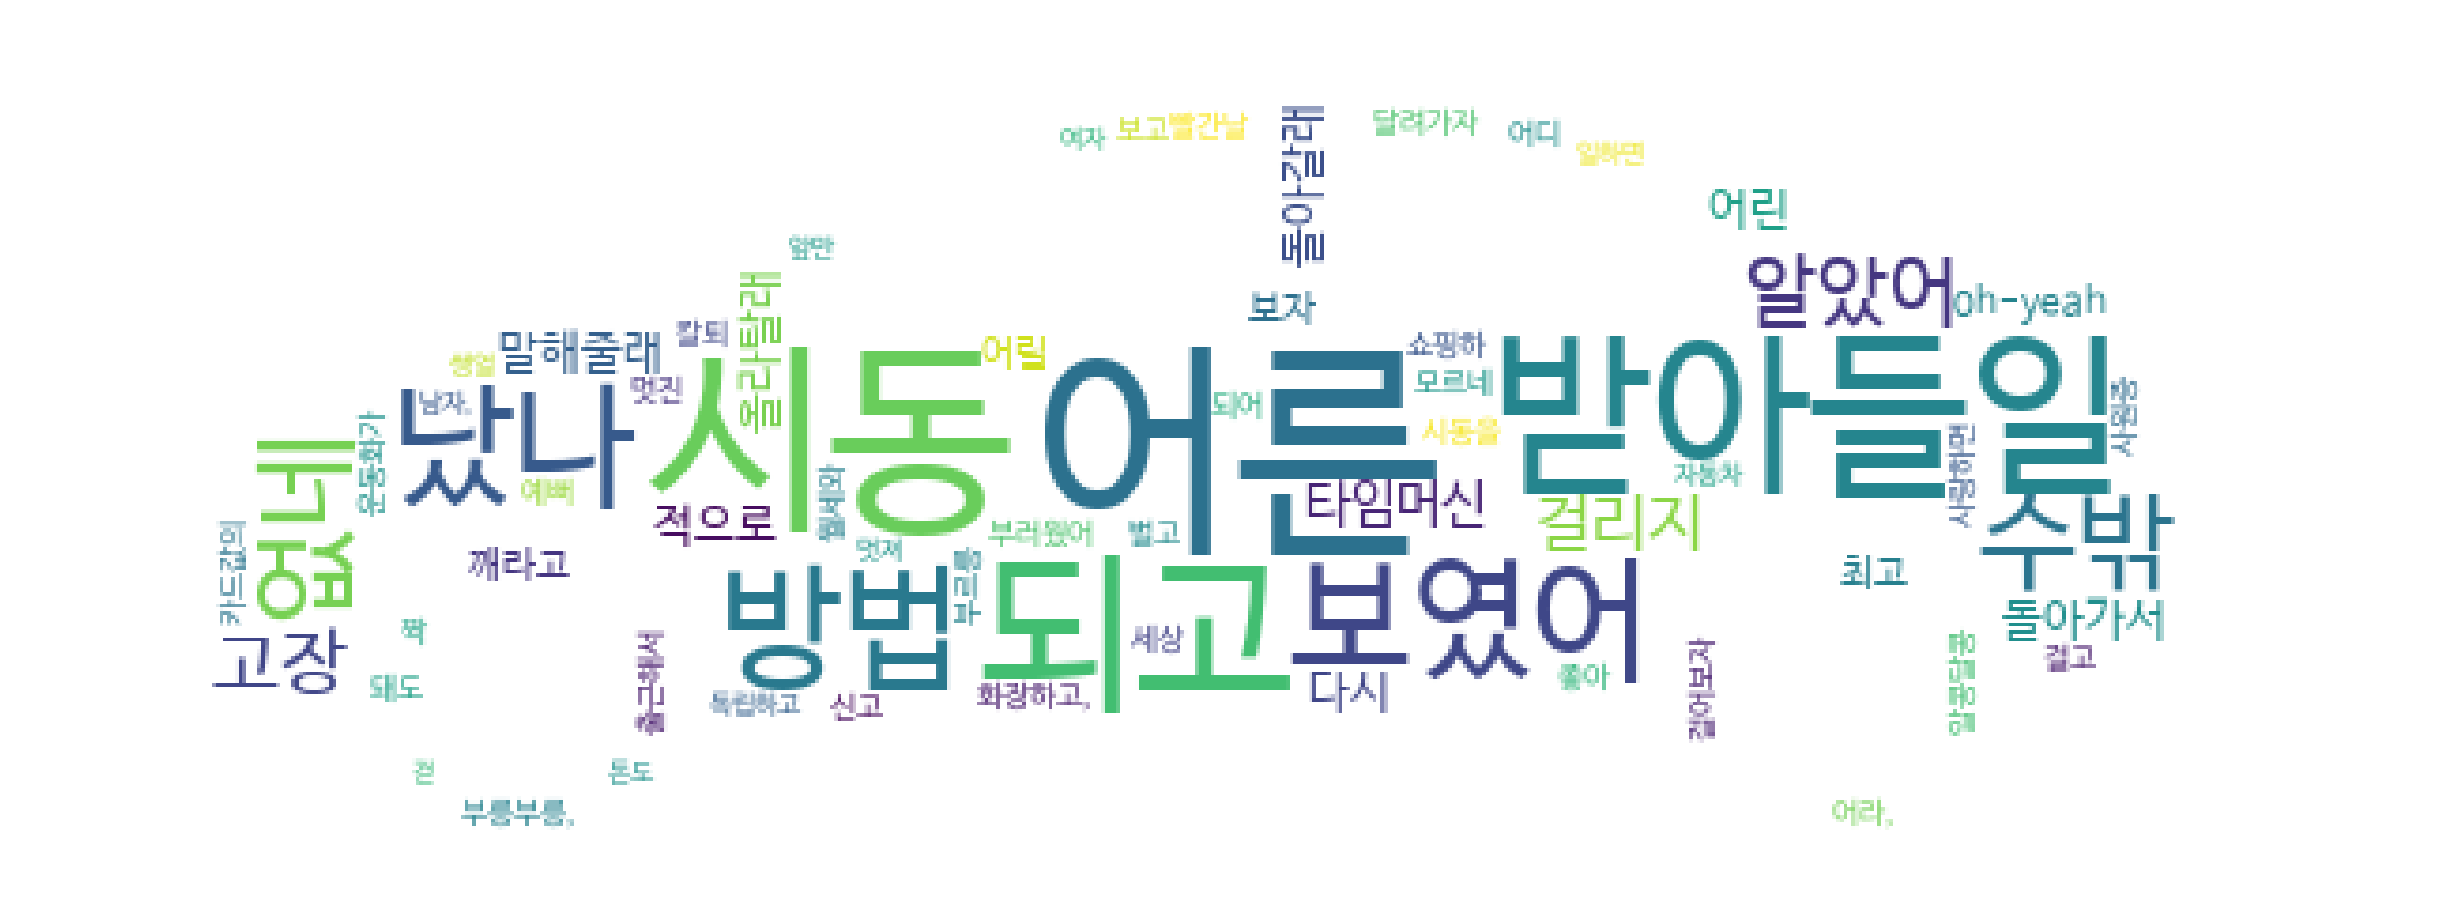

In [ ]:
# 라이브러리 불러오기
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 라이브러리 불러오기
import numpy as np
from PIL import Image

# 이미지를 불러오기
masking_image = np.array(Image.open('car.jpg'))


wordcloud = WordCloud(
    font_path='./assets/NanumBarunGothic.ttf',
    width=2000,
    height=1000,
    mask = masking_image,
    max_font_size=60,
    # min_font_size=10,
    background_color='white',
    color_func=lamba
).generate_from_frequencies(wordCount)

#표시하기
plt.figure(figsize=(12,6)) # 그래프(figure) 크기 설정 (가로 12, 세로 6 인치)
plt.imshow(wordcloud) # 워드클라우드 이미지를 화면에 표시
plt.axis('off') # x축, y축 눈금 제거 -> 깔끔하게 보이게 함
plt.tight_layout(pad=0) # 그래프 여백 최소화 (이미지가 꽉 차게)
plt.show() # 최종적으로 화면에 출력



In [98]:
f = open('./assets/korea.txt', 'r',encoding='UTF-8')

text = f.read()

f.close()

text[:100]

# print(text.split())
wordlist = []


# 한글자, 마침표가 있는 단어 제거

import re

for x in text.split():
    if '.' in x:
        pass
    elif len(x) == 1:
        pass
    elif '항' in x:
        pass
    else:
        wordlist.append(x)

print(wordlist)



['전문', '유구한', '역사와', '전통에', '빛나는', '우리', '대한국민은', '3ㆍ1운동으로', '건립된', '대한민국임시정부의', '법통과', '불의에', '4ㆍ19민주이념을', '계승하고,', '조국의', '민주개혁과', '평화적', '통일의', '사명에', '입각하여', '정의ㆍ인도와', '동포애로써', '민족의', '단결을', '공고히', '하고,', '모든', '사회적', '폐습과', '불의를', '타파하며,', '자율과', '조화를', '바탕으로', '자유민주적', '기본질서를', '더욱', '확고히', '하여', '정치ㆍ경제ㆍ사회ㆍ문화의', '모든', '영역에', '있어서', '각인의', '기회를', '균등히', '하고,', '능력을', '최고도로', '발휘하게', '하며,', '자유와', '권리에', '따르는', '책임과', '의무를', '완수하게', '하여,', '안으로는', '국민생활의', '균등한', '향상을', '기하고', '밖으로는', '세계평화와', '인류공영에', '이바지함으로써', '우리들과', '우리들의', '자손의', '안전과', '자유와', '행복을', '영원히', '확보할', '것을', '다짐하면서', '1948년', '7월', '12일에', '제정되고', '8차에', '걸쳐', '개정된', '헌법을', '이제', '국회의', '의결을', '거쳐', '국민투표에', '의하여', '1987년', '10월', '29일', '제1장', '총강', '조문체계도버튼', '제1조', '①대한민국은', '②대한민국의', '주권은', '국민에게', '있고,', '모든', '권력은', '국민으로부터', '조문체계도버튼', '제2조', '①대한민국의', '국민이', '되는', '요건은', '법률로', '②국가는', '법률이', '정하는', '바에', '의하여', '재외국민을', '보호할', '의무를', '조문체계도버튼', '제3조', '대한민국의', '영토는', '한반도와', '부속도서로', '조문체계도버튼', '제4조', '대한

In [96]:
# 중복단어 제거
clean_text = set(wordlist)
wordCount = {}

# print(clean_text)

for w in clean_text:
    wordCount[w] = text.count(w)

print(wordCount)

# 불용어 제거 (조사 제거)
stop_words = ['근데', '수밖에', '그럼','하여', '또는', '하며']

# 제외하기
for w in stop_words:
    if w in wordCount:
        del wordCount[w]

print(wordCount)


{'문서로써': 1, '공포한': 3, '제112조': 1, '긴급한': 2, '정치적': 5, '평등을': 1, '60일': 2, '제29조': 1, '회계검사와': 1, '하되,': 4, '선전ㆍ강화': 1, '출석과': 3, '제1관': 1, '국회에서': 5, '제청에': 1, '면제되지는': 1, '또한': 2, '더욱': 1, '합리적인': 1, '국가': 73, '직책을': 1, '규정을': 1, '대법원장과': 3, '제78조': 1, '아니하며,': 6, '기타': 26, '국제법과': 1, '위임받은': 1, '부결된': 1, '발의가': 1, '범죄를': 1, '여자의': 2, '제15조': 1, '보장에': 3, '자신의': 1, '평화적': 4, '대학의': 1, '영원히': 1, '국민으로부터': 1, '국정처리상황을': 1, '행정심판의': 1, '자녀에게': 1, '④재의의': 1, '가격안정을': 1, '복권을': 1, '임명하는': 1, '법률로': 35, '제13조': 1, '관리': 15, '거쳐': 2, '자의로': 1, '선서를': 1, '의사와': 1, '⑤국가는': 2, '관하여': 15, '처벌할': 1, '있으면': 1, '집행할': 1, '교전상태에': 1, '국가원로자문회의를': 1, '개시': 5, '저촉되지': 4, '개시될': 1, '설치할': 1, '선고에': 3, '침해한': 1, '국정에': 1, '붙이고,': 1, '보위하기': 1, '장기화': 1, '상당한': 1, '위원으로': 5, '의회를': 1, '재판관으로': 1, '적법한': 2, '명하려면': 2, '5일': 3, '존속하며': 1, '처분이': 1, '외에서': 1, '창의를': 1, '대한국민은': 1, '권한의': 2, '통제': 1, '새로운': 2, '제61조': 1, '국회의장이': 1, '대통령ㆍ국무총리와': 1, '집회일': 2, '정치에': 2, '예산으로': 1, '내용을': 1, '이익을': 2, '공직으로부터':

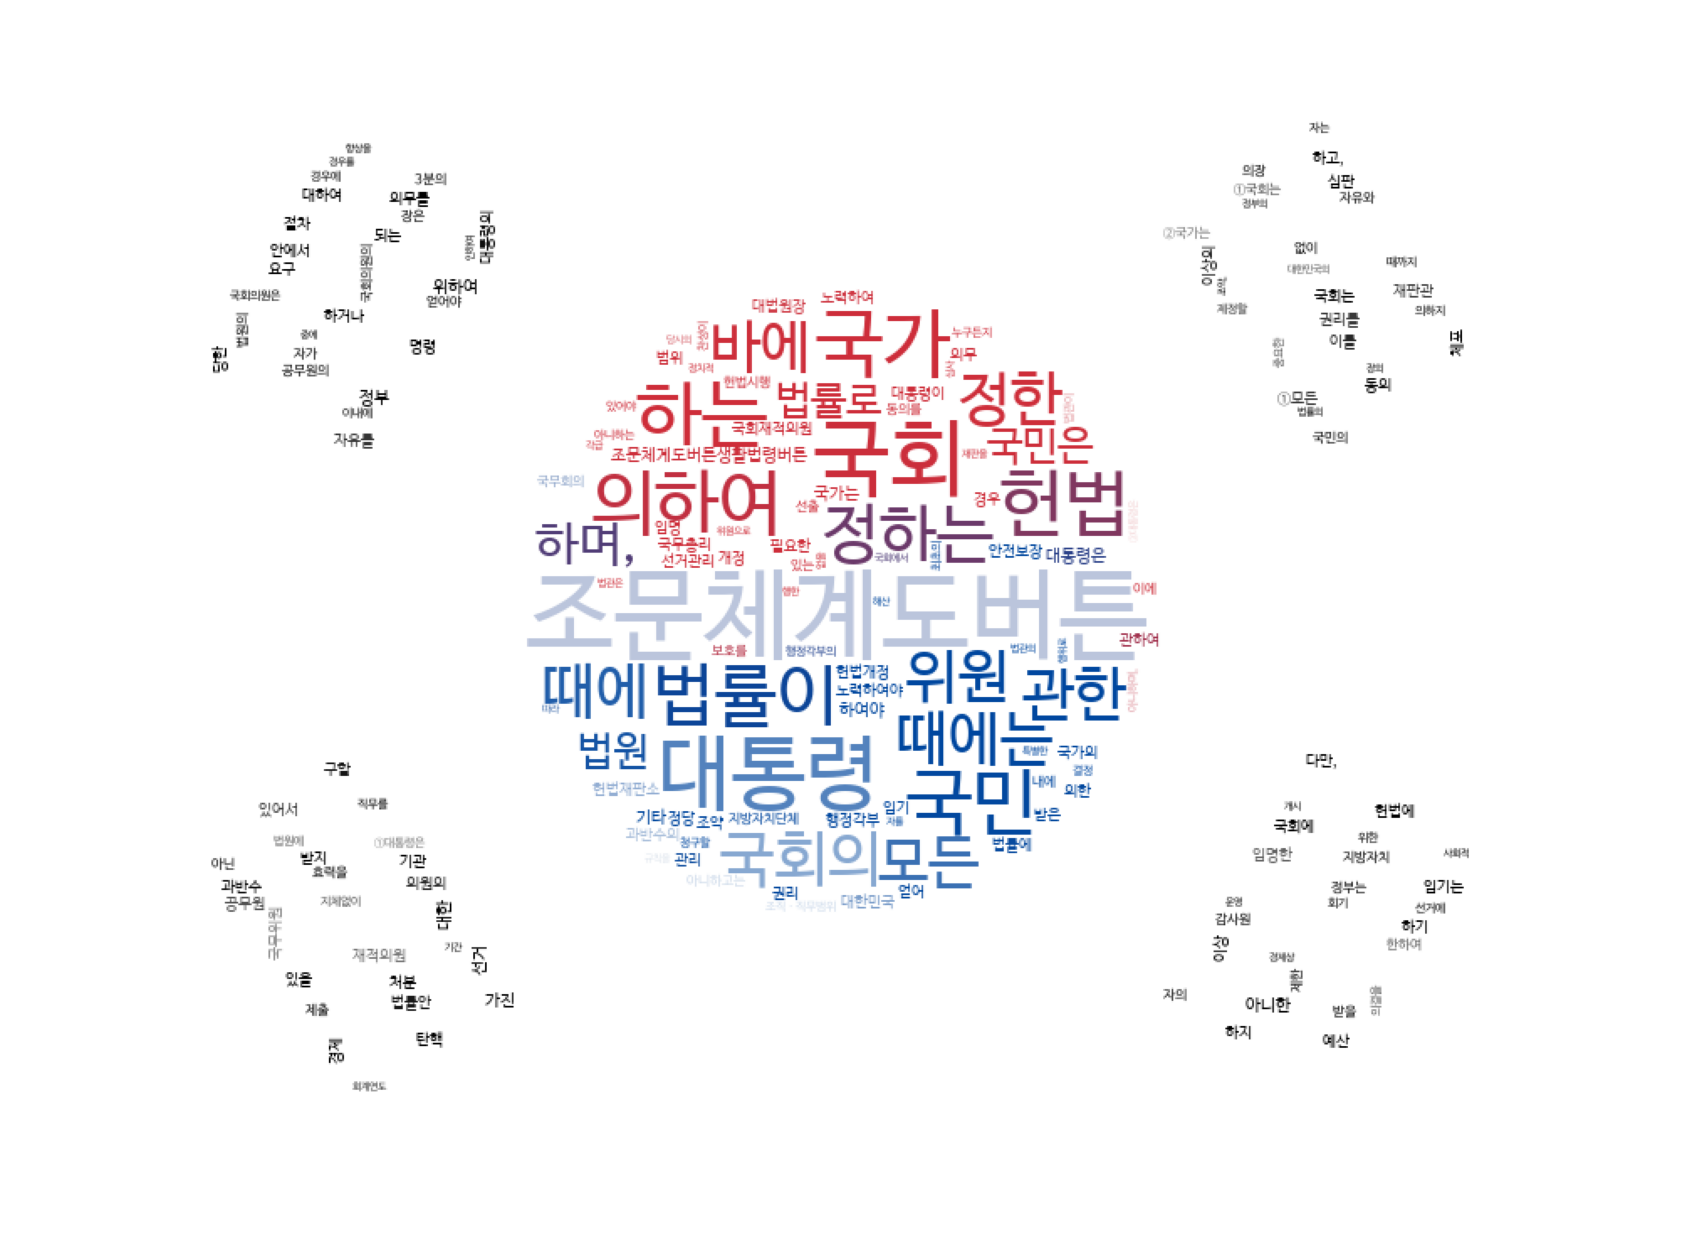

In [ ]:
# 라이브러리 불러오기
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 라이브러리 불러오기
import numpy as np
from PIL import Image

# 이미지를 불러오기
masking_image = np.array(Image.open('korea.jpg'))

from wordcloud import WordCloud, ImageColorGenerator
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

masking_image = np.array(Image.open('korea.jpg'))

# 이미지 색상을 그대로 글자에 적용
color_func = ImageColorGenerator(masking_image)

wordcloud = WordCloud(
    font_path='./assets/NanumBarunGothic.ttf',
    width=2000,
    height=1000,
    mask=masking_image,
    max_font_size=80,
    background_color='white',
    color_func=color_func
).generate_from_frequencies(wordCount)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

